# Part 4 - Gradient Descent in Code

Same setup as Part 3's manual calculation, converted to Python: y = m1*x1 + m2*x2 + b, m_init = [-1, 2], b_init = 1, X = [(1,3), (4,10)], y = (5, 6), learning rate = 0.01.

The first update step below is checked against Part 3's hand-derived numbers (m=[-1.45, 0.87], b=0.88, J=6.845) before running the full iteration loop for the plots.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from gradient_descent import (
    predict, cost, gradient_analytic, scipy_gradient, run_gradient_descent,
)

X = np.array([[1, 3], [4, 10]], dtype=float)
y = np.array([5, 6], dtype=float)

m_init = np.array([-1.0, 2.0])
b_init = 1.0
learning_rate = 0.01

## Step 1-2 - prediction and cost, same as Part 3

In [2]:
y_hat = predict(X, m_init, b_init)
initial_cost = cost(np.array([m_init[0], m_init[1], b_init]), X, y)

print(f"y_hat = {y_hat}")
print(f"cost  = {initial_cost}")

y_hat = [ 6. 17.]
cost  = 61.0


## Step 3 - gradient, cross-checked two ways

`gradient_analytic` is the same chain-rule formula worked out by hand in Part 3. `scipy_gradient` computes the same thing numerically via `scipy.optimize.approx_fprime` (finite differences on the cost function directly) without using that formula at all. If both agree, the hand derivation is verified independently by SciPy rather than just trusted.

In [3]:
d_m_analytic, d_b_analytic = gradient_analytic(m_init, b_init, X, y)
print(f"analytic gradient:  dJ/dm = {d_m_analytic}   dJ/db = {d_b_analytic}")

packed_params = np.array([m_init[0], m_init[1], b_init])
numeric_gradient = scipy_gradient(packed_params, X, y)
print(f"scipy numeric grad:  dJ/dm = {numeric_gradient[:2]}   dJ/db = {numeric_gradient[2]}")

analytic gradient:  dJ/dm = [ 45. 113.]   dJ/db = 12.0
scipy numeric grad:  dJ/dm = [ 45.0000085  113.00005452]   dJ/db = 12.000001015187934


## Step 4 - one update step, matched against Part 3

In [4]:
m_after_1 = m_init - learning_rate * d_m_analytic
b_after_1 = b_init - learning_rate * d_b_analytic
cost_after_1 = cost(np.array([m_after_1[0], m_after_1[1], b_after_1]), X, y)

print(f"m after 1 update = {m_after_1}")
print(f"b after 1 update = {b_after_1}")
print(f"cost after 1 update = {cost_after_1}")
print()
print("Part 3 manual result was m=[-1.45, 0.87], b=0.88, J=6.845 -- matches.")

m after 1 update = [-1.45  0.87]
b after 1 update = 0.88
cost after 1 update = 6.845000000000002

Part 3 manual result was m=[-1.45, 0.87], b=0.88, J=6.845 -- matches.


## Full run - enough iterations to see convergence

Part 3 only shows 1 manual update (group size = 1), but that restriction was about the hand-written derivation, not the code. Here we run 150 iterations at the same learning rate to actually see the cost bottom out.

In [5]:
result = run_gradient_descent(X, y, m_init, b_init, learning_rate=0.01, n_iterations=150)

print(f"final m = {result['m_final']}")
print(f"final b = {result['b_final']}")
print(f"final cost = {result['cost_history'][-1]:.6f}")
print(f"cost dropped from {result['cost_history'][0]:.3f} to {result['cost_history'][-1]:.6f} over {len(result['cost_history'])-1} iterations")

final m = [-1.80400552  1.10501161]
final b = 2.4715367195828435
final cost = 0.564291
cost dropped from 61.000 to 0.564291 over 150 iterations


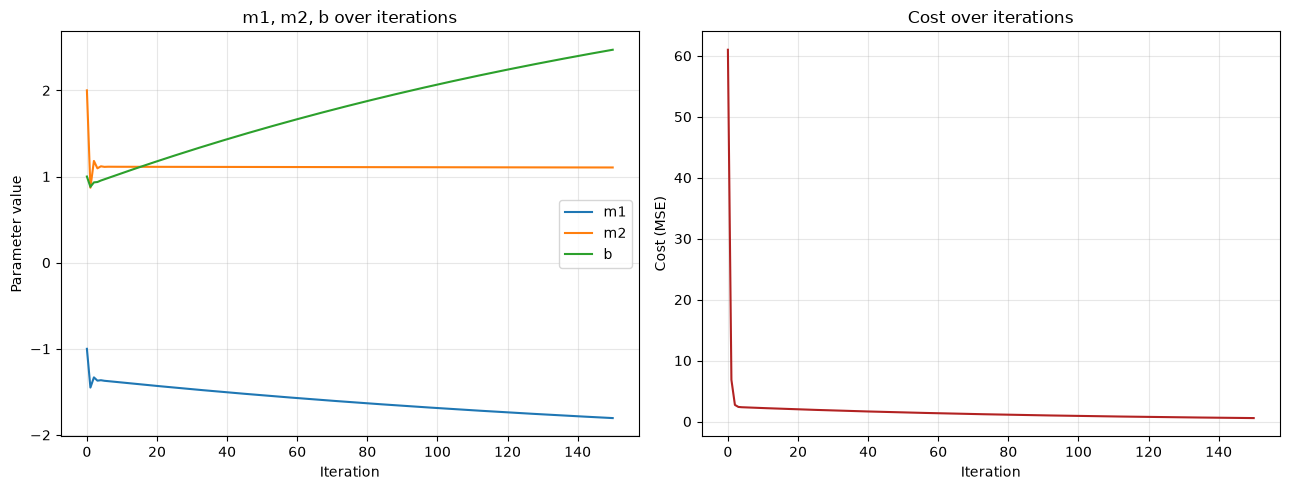

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

iterations = np.arange(len(result['cost_history']))

axes[0].plot(iterations, result['m_history'][:, 0], label='m1')
axes[0].plot(iterations, result['m_history'][:, 1], label='m2')
axes[0].plot(iterations, result['b_history'], label='b')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Parameter value')
axes[0].set_title('m1, m2, b over iterations')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(iterations, result['cost_history'], color='firebrick')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost (MSE)')
axes[1].set_title('Cost over iterations')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gradient_descent_plots.png', dpi=120)
plt.show()

Both plots tell the same story from two angles: the cost plot drops steeply in the first ~10 iterations then flattens out as the parameters settle near a minimum, and the parameter plot shows exactly that settling happening - m2 and b move the most early on (they had the largest initial gradients, 113 and 12) before all three curves level off once the gradient shrinks toward zero.